✅ pytrends already installed


✅ All imports successful
Total stocks: 41 across 6 sectors

Sector breakdown:
  Technology: 10 stocks
  Finance: 8 stocks
  Energy: 6 stocks
  Healthcare: 6 stocks
  Consumer: 6 stocks
  Industrial: 5 stocks



✅ Downloaded 41/41 stocks

Fitting GARCH models...

Fitting GARCH models for 41 stocks

Fitting NVDA... ✓ (α+β=0.967, ν=5.7)
Fitting AMD... ✓ (α+β=0.798, ν=3.6)
Fitting INTC... ✓ (α+β=0.886, ν=3.3)
Fitting QCOM... ✓ (α+β=0.237, ν=3.2)
Fitting MU... ✓ (α+β=0.932, ν=5.6)
Fitting TSM... ✓ (α+β=0.760, ν=5.8)
Fitting ASML... ✓ (α+β=0.696, ν=3.8)
Fitting MSFT... ✓ (α+β=0.896, ν=3.5)
Fitting GOOGL... ✓ (α+β=0.837, ν=4.5)
Fitting META... ✓ (α+β=0.890, ν=3.8)
Fitting JPM... ✓ (α+β=0.659, ν=3.9)
Fitting BAC... ✓ (α+β=0.785, ν=4.0)
Fitting WFC... ✓ (α+β=0.680, ν=3.8)
Fitting C... ✓ (α+β=0.884, ν=4.4)
Fitting GS... ✓ (α+β=0.743, ν=4.3)
Fitting MS... ✓ (α+β=0.838, ν=3.5)
Fitting AXP... ✓ (α+β=0.786, ν=3.7)
Fitting V... ✓ (α+β=0.859, ν=3.6)
Fitting XOM... ✓ (α+β=0.884, ν=10.9)
Fitting CVX... 

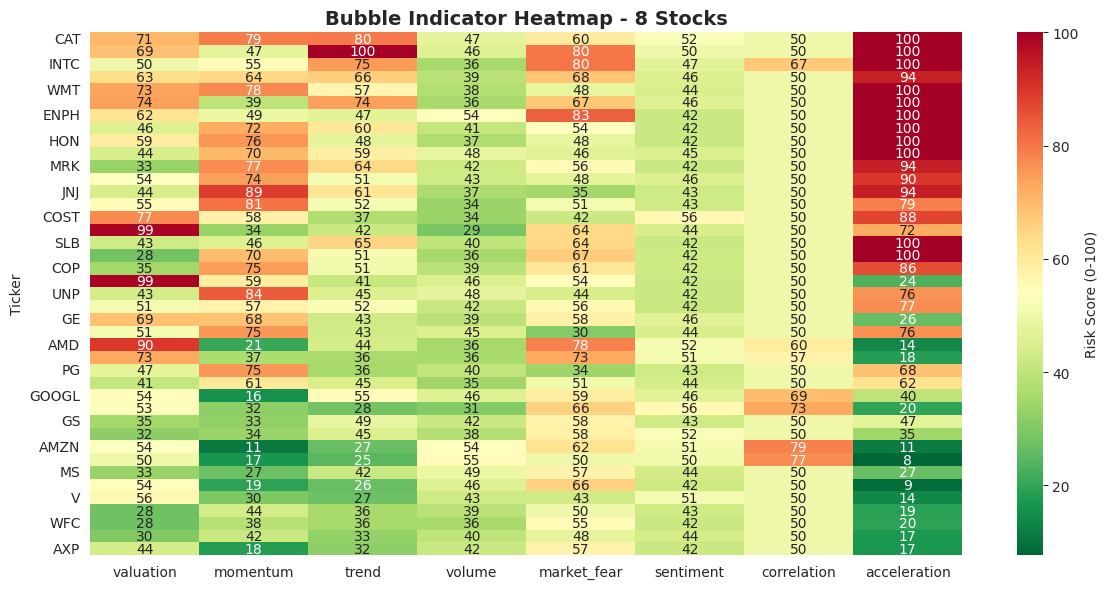

✅ Risk heatmap generated


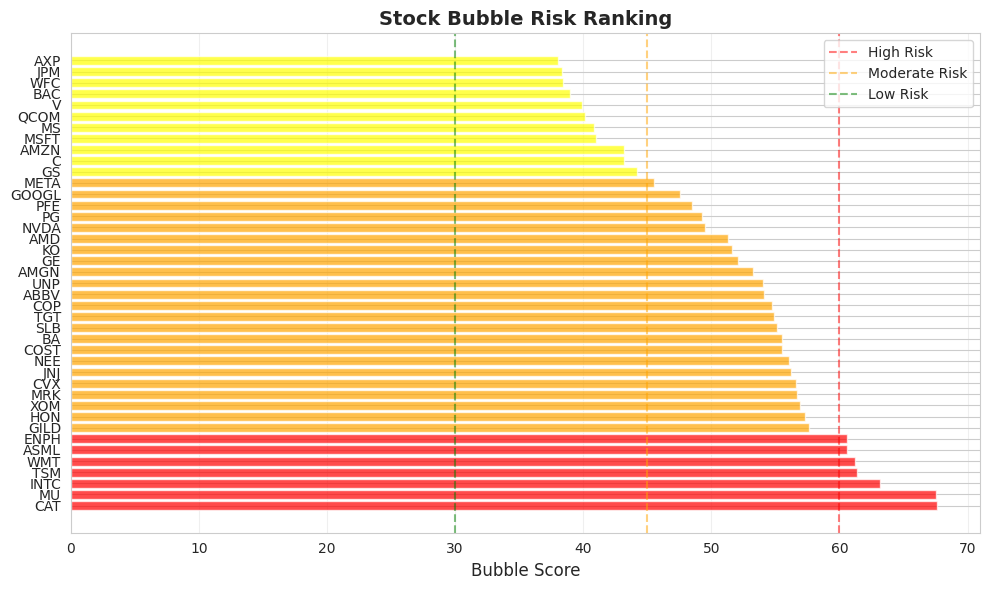

✅ Bubble score ranking chart generated


In [1]:
# CELL 1: Setup and Imports
import subprocess
import sys

# Force install pytrends in notebook kernel
try:
    import pytrends
    print("✅ pytrends already installed")
except ImportError:
    print("Installing pytrends in notebook kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pytrends", "-q"])
    print("✅ pytrends installed")

import os
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(repo_root)

from src.models.bubble_indicators import BubbleRiskAnalyzer
from src.models.garch import MultiStockGARCH
from src.models.monte_carlo_advanced import JumpDiffusionMC
from src.data.fetch import download_multiple_stocks, calculate_returns_multiple
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("✅ All imports successful")
# CELL 2: Download Data
# CELL 2: Download Data - 40 STOCKS ACROSS ALL SECTORS
tickers = {
    'Technology': ['NVDA', 'AMD', 'INTC', 'QCOM', 'MU', 'TSM', 'ASML', 'MSFT', 'GOOGL', 'META'],
    'Finance': ['JPM', 'BAC', 'WFC', 'C', 'GS', 'MS', 'AXP', 'V'],
    'Energy': ['XOM', 'CVX', 'COP', 'SLB', 'NEE', 'ENPH'],
    'Healthcare': ['JNJ', 'PFE', 'ABBV', 'MRK', 'GILD', 'AMGN'],
    'Consumer': ['AMZN', 'WMT', 'TGT', 'PG', 'KO', 'COST'],
    'Industrial': ['BA', 'CAT', 'GE', 'UNP', 'HON']
}

# Flatten to single list
all_tickers = []
for sector, stocks in tickers.items():
    all_tickers.extend(stocks)

print(f"Total stocks: {len(all_tickers)} across {len(tickers)} sectors")
print("\nSector breakdown:")
for sector, stocks in tickers.items():
    print(f"  {sector}: {len(stocks)} stocks")

# Download data
end = datetime.now().strftime('%Y-%m-%d')
start = (datetime.now() - timedelta(days=730)).strftime('%Y-%m-%d')  # 2 years

print(f"\nDownloading {len(all_tickers)} stocks from {start} to {end}...\n")
data_dict = download_multiple_stocks(all_tickers, start, end)
returns_dict = calculate_returns_multiple(data_dict)

successful = sum(1 for d in data_dict.values() if d is not None and not d.empty)
print(f"\n✅ Downloaded {successful}/{len(all_tickers)} stocks")

# CELL 3: Batch GARCH
print("\nFitting GARCH models...")
garch_processor = MultiStockGARCH(returns_dict)
garch_processor.fit_all()
forecasts_dict = garch_processor.forecast_all(180)
current_vols = garch_processor.get_current_volatilities()

# Convert forecasts to average values
forecasts = {ticker: arr.mean() if arr is not None else None 
             for ticker, arr in forecasts_dict.items()}

print("\n✅ GARCH forecasts ready")

# CELL 4: Calculate Bubble Scores
print("\nCalculating bubble scores for all stocks...\n")

bubble_scores = {}
for ticker in all_tickers:  # Use all_tickers, not tickers
    if data_dict.get(ticker) is not None:
        try:
            analyzer = BubbleRiskAnalyzer(ticker, lookback_days=365)
            result = analyzer.get_composite_score()
            bubble_scores[ticker] = result
            print(f"{ticker}: {result['composite_score']:.1f}/100 - {result['interpretation']}")
        except Exception as e:
            print(f"{ticker}: Error - {e}")

print(f"\n✅ Calculated bubble scores for {len(bubble_scores)} stocks")

# CELL 5: Create Risk Ranking Table
risk_data = []

for ticker in bubble_scores.keys():
    garch_vol = current_vols.get(ticker, None)
    forecast_vol = forecasts.get(ticker, None)
    
    risk_data.append({
        'Ticker': ticker,
        'Bubble Score': bubble_scores[ticker]['composite_score'],
        'GARCH Vol (%)': garch_vol * 100 if garch_vol is not None else 0,
        'Forecast Vol (%)': forecast_vol * 100 if forecast_vol is not None else 0,
        'Interpretation': bubble_scores[ticker]['interpretation']
    })

risk_df = pd.DataFrame(risk_data)
risk_df = risk_df.sort_values('Bubble Score', ascending=False)

print("\n" + "="*80)
print("MULTI-STOCK RISK RANKING")
print("="*80)
print(risk_df.to_string(index=False))
print("="*80)

# CELL 6: Visualization - Risk Heatmap
fig, ax = plt.subplots(figsize=(12, 6))

heatmap_data = []
for ticker in risk_df['Ticker']:
    scores = bubble_scores[ticker]['indicators']
    heatmap_data.append(list(scores.values()))

heatmap_df = pd.DataFrame(
    heatmap_data,
    columns=list(bubble_scores[list(bubble_scores.keys())[0]]['indicators'].keys()),
    index=risk_df['Ticker']
)

sns.heatmap(heatmap_df, annot=True, fmt='.0f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Risk Score (0-100)'}, ax=ax)
ax.set_title('Bubble Indicator Heatmap - 8 Stocks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Risk heatmap generated")

# CELL 7: Visualization - Bubble Score Ranking
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['red' if x >= 60 else 'orange' if x >= 45 else 'yellow' if x >= 30 else 'green' 
          for x in risk_df['Bubble Score']]

ax.barh(risk_df['Ticker'], risk_df['Bubble Score'], color=colors, alpha=0.7)
ax.axvline(x=60, color='red', linestyle='--', alpha=0.5, label='High Risk')
ax.axvline(x=45, color='orange', linestyle='--', alpha=0.5, label='Moderate Risk')
ax.axvline(x=30, color='green', linestyle='--', alpha=0.5, label='Low Risk')

ax.set_xlabel('Bubble Score', fontsize=12)
ax.set_title('Stock Bubble Risk Ranking', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Bubble score ranking chart generated")